# Reto Semanal 4: TextCNN para Deteccion de Fake News

**Nombre:** Zhang Tan Rubi

**Objetivo:** Entrenar y evaluar un modelo TextCNN para clasificar noticias del dataset WELFake.

### Entregables:

| # | Tarea | Descripcion |
|---|-------|-------------|
| 1 | Pipeline | Usa el pipeline del Reto 3 (vocabulario, DataLoaders, GloVe) |
| 2 | Modelo random | TextCNN con kernels [3,4,5], 100 filtros, dropout=0.5, embeddings aleatorios |
| 3 | Modelo GloVe | Mismo modelo pero inicializado con embeddings GloVe preentrenados |
| 4 | Entrenamiento | 10 epocas, Adam lr=1e-3, BCEWithLogitsLoss, early stopping (patience=3) |
| 5 | Curvas | Grafica loss y F1 de train/val para ambos modelos |
| 6 | Comparacion | Tabla: Random vs GloVe (loss, accuracy, F1, precision, recall en test) |
| 7 | vs Baselines | Agrega los resultados del Reto 2 a la tabla comparativa |
| 8 | Reflexion | Los embeddings preentrenados convergieron mas rapido? Por que? |

### Metricas esperadas:
- TextCNN con GloVe: F1 ~0.95-0.97
- Debe superar los baselines del Reto 2 (~0.93-0.94)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
!{sys.executable} -m pip install nltk
import nltk
nltk.download('stopwords', quiet=True)

True

## RETO 4.1 — Preparar datos y modelo

In [ ]:
import sys, os, re
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

sys.path.insert(0, "/content/drive/MyDrive/ModeladoPredictivo2026/notebooks")

from src.dataset  import build_vocabulary, FakeNewsDataset, create_dataloaders, load_glove, PAD_IDX, UNK_IDX
from src.model    import TextCNN
from src.train    import train_model
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix, plot_training_curves

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cpu


In [ ]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    # Convertir a minúsculas
    text = text.lower()
    # Normalizar apóstrofos tipográficos
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    # Separar cualquier símbolo no alfanumérico pegado a letras
    text = re.sub(r"([a-zA-Z])([^a-zA-Z0-9\s])", r"\1 \2", text)
    text = re.sub(r"([^a-zA-Z0-9\s])([a-zA-Z])", r"\1 \2", text)
    # Eliminar tokens que no contengan ninguna letra
    words = text.split()
    words = [w for w in words if re.search(r"[a-zA-Z]", w)]
    # Eliminar stopwords
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [ ]:
# TODO: Cargar datos, vocabulario, embeddings GloVe (del Reto 3)
# Cargar y limpiar dataset
df_reto = pd.read_csv('/content/drive/MyDrive/ModeladoPredictivo2026/data/WELFake_limpio.csv')
df_reto = df_reto.dropna(subset=["text", "label"])
df_reto["label"] = df_reto["label"].astype(int)   # 0 = fake, 1 = real
df_reto["text"]  = df_reto["text"].apply(remove_stopwords)

texts  = df_reto["text"].tolist()
labels = df_reto["label"].tolist()

# Split estratificado 80 / 10 / 10
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.20, random_state=42, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

# Vocabulario SOLO con train
word2idx = build_vocabulary(train_texts, max_vocab=20_000)

print(f"Train: {len(train_texts):,} | Val: {len(val_texts):,} | Test: {len(test_texts):,}")
print(f"Vocabulario: {len(word2idx):,} palabras (incluye <PAD>={PAD_IDX} y <UNK>={UNK_IDX})")

Train: 50,488 | Val: 6,311 | Test: 6,311
Vocabulario: 20,002 palabras (incluye <PAD>=0 y <UNK>=1)


In [ ]:
# TODO: Crear DataLoaders
from torch.utils.data import DataLoader, Dataset

class NewsDataset(Dataset):
    """Dataset que devuelve diccionarios compatibles con src/train.py"""
    def __init__(self, texts, labels, word2idx, max_len=200):
        self.max_len  = max_len
        self.labels   = labels
        self.sequences = []
        for text in texts:
            tokens = [word2idx.get(w, UNK_IDX) for w in text.split()[:max_len]]
            tokens += [PAD_IDX] * (max_len - len(tokens))
            self.sequences.append(tokens)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.sequences[idx], dtype=torch.long),
            "labels":    torch.tensor(self.labels[idx],    dtype=torch.float32),
        }

BATCH_SIZE = 64

train_loader = DataLoader(NewsDataset(train_texts, train_labels, word2idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NewsDataset(val_texts,   val_labels,   word2idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NewsDataset(test_texts,  test_labels,  word2idx), batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(f"batch['input_ids'].shape = {batch['input_ids'].shape}")
print(f"batch['labels'].shape    = {batch['labels'].shape}")


batch['input_ids'].shape = torch.Size([64, 200])
batch['labels'].shape    = torch.Size([64])


In [ ]:
# Cargar GloVe 50d
from pathlib import Path

GLOVE_PATH = Path('/content/drive/MyDrive/ModeladoPredictivo2026/data/glove.6B.50d.txt')

embedding_matrix = load_glove(
    glove_path=str(GLOVE_PATH),
    word2idx=word2idx,
    embed_dim=50,
)
print(f"Matriz de embeddings: {embedding_matrix.shape}")


GloVe cargado: 19,742 / 20,002 palabras encontradas (98.7% de cobertura)
Matriz de embeddings: (20002, 50)


In [ ]:
VOCAB_SIZE = len(word2idx)

# TODO: Instanciar TextCNN con embeddings aleatorios
model_random = TextCNN(
    vocab_size=VOCAB_SIZE, embed_dim=50, num_filters=100,
    kernel_sizes=[3, 4, 5], dropout=0.5,
    pretrained_embeddings=None,
).to(device)

# TODO: Instanciar TextCNN con embeddings GloVe
model_glove = TextCNN(
    vocab_size=VOCAB_SIZE, embed_dim=50, num_filters=100,
    kernel_sizes=[3, 4, 5], dropout=0.5,
    pretrained_embeddings=embedding_matrix,
).to(device)

print(model_random)
print(f"\nParámetros totales     : {sum(p.numel() for p in model_random.parameters()):,}")
print(f"Parámetros entrenables : {sum(p.numel() for p in model_random.parameters() if p.requires_grad):,}")


TextCNN(
  (embedding): Embedding(20002, 50, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(50, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(50, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(50, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

Parámetros totales     : 1,060,701
Parámetros entrenables : 1,060,701


## RETO 4.2 — Entrenar ambos modelos

In [ ]:
# TODO: Entrenar model_random (10 epocas, Adam lr=1e-3, patience=3)
criterion = nn.BCEWithLogitsLoss()

print("ENTRENAMIENTO: TextCNN con embeddings ALEATORIOS")

optimizer_random = torch.optim.Adam(model_random.parameters(), lr=1e-3)

history_random = train_model(
    model=model_random,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_random,
    criterion=criterion,
    device=device,
    num_epochs=10,
    patience=3,
)


ENTRENAMIENTO: TextCNN con embeddings ALEATORIOS
Epoch 01/10 | Train Loss: 0.4175  Train F1: 0.7649 | Val Loss: 0.2618  Val F1: 0.8755
Epoch 02/10 | Train Loss: 0.2662  Train F1: 0.8714 | Val Loss: 0.2211  Val F1: 0.8947
Epoch 03/10 | Train Loss: 0.2219  Train F1: 0.8977 | Val Loss: 0.1985  Val F1: 0.9066
Epoch 04/10 | Train Loss: 0.1903  Train F1: 0.9131 | Val Loss: 0.1832  Val F1: 0.9113
Epoch 05/10 | Train Loss: 0.1603  Train F1: 0.9279 | Val Loss: 0.1817  Val F1: 0.9180
Epoch 06/10 | Train Loss: 0.1402  Train F1: 0.9375 | Val Loss: 0.1741  Val F1: 0.9191
Epoch 07/10 | Train Loss: 0.1194  Train F1: 0.9478 | Val Loss: 0.1761  Val F1: 0.9228
Epoch 08/10 | Train Loss: 0.1024  Train F1: 0.9555 | Val Loss: 0.1855  Val F1: 0.9247
Epoch 09/10 | Train Loss: 0.0851  Train F1: 0.9640 | Val Loss: 0.1930  Val F1: 0.9226
Epoch 10/10 | Train Loss: 0.0722  Train F1: 0.9694 | Val Loss: 0.2113  Val F1: 0.9196


In [ ]:
# TODO: Entrenar model_glove (misma configuracion)
print("ENTRENAMIENTO: TextCNN con embeddings GloVe PREENTRENADOS")

optimizer_glove = torch.optim.Adam(model_glove.parameters(), lr=1e-3)

history_glove = train_model(
    model=model_glove,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_glove,
    criterion=criterion,
    device=device,
    num_epochs=10,
    patience=3,
)


ENTRENAMIENTO: TextCNN con embeddings GloVe PREENTRENADOS
Epoch 01/10 | Train Loss: 0.3046  Train F1: 0.8455 | Val Loss: 0.1942  Val F1: 0.9168
Epoch 02/10 | Train Loss: 0.1679  Train F1: 0.9243 | Val Loss: 0.1570  Val F1: 0.9296
Epoch 03/10 | Train Loss: 0.1180  Train F1: 0.9496 | Val Loss: 0.1520  Val F1: 0.9293
Epoch 04/10 | Train Loss: 0.0836  Train F1: 0.9667 | Val Loss: 0.1608  Val F1: 0.9286
Epoch 05/10 | Train Loss: 0.0554  Train F1: 0.9782 | Val Loss: 0.1779  Val F1: 0.9290

Early stopping en epoca 5. Mejor Val F1: 0.9296


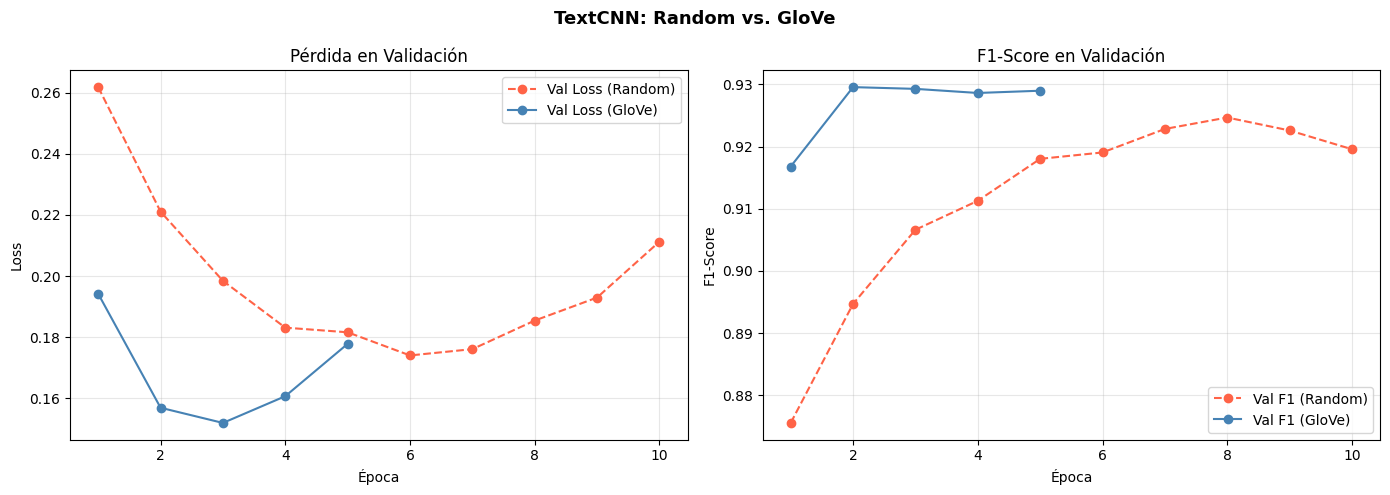

In [ ]:
# TODO: Graficar curvas de loss y F1 lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_r = range(1, len(history_random["train_loss"]) + 1)
epochs_g = range(1, len(history_glove["train_loss"])  + 1)

axes[0].plot(epochs_r, history_random["val_loss"], "o--", label="Val Loss (Random)", color="tomato")
axes[0].plot(epochs_g, history_glove["val_loss"],  "o-",  label="Val Loss (GloVe)",  color="steelblue")
axes[0].set_title("Pérdida en Validación"); axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_r, history_random["val_f1"], "o--", label="Val F1 (Random)", color="tomato")
axes[1].plot(epochs_g, history_glove["val_f1"],  "o-",  label="Val F1 (GloVe)",  color="steelblue")
axes[1].set_title("F1-Score en Validación"); axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1-Score"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("TextCNN: Random vs. GloVe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## RETO 4.3 — Evaluacion y tabla comparativa

In [ ]:
# TODO: Evaluar ambos modelos en test
metrics_random = evaluate_model(model_random, test_loader, criterion, device)
metrics_glove  = evaluate_model(model_glove,  test_loader, criterion, device)

print("Resultados en Test:")
print(f"  Random — Accuracy: {metrics_random['accuracy']:.4f}  F1: {metrics_random['f1']:.4f}  "
      f"Precision: {metrics_random['precision']:.4f}  Recall: {metrics_random['recall']:.4f}")
print(f"  GloVe  — Accuracy: {metrics_glove['accuracy']:.4f}  F1: {metrics_glove['f1']:.4f}  "
      f"Precision: {metrics_glove['precision']:.4f}  Recall: {metrics_glove['recall']:.4f}")


Resultados en Test:
  Random — Accuracy: 0.9270  F1: 0.9198  Precision: 0.9070  Recall: 0.9329
  GloVe  — Accuracy: 0.9296  F1: 0.9224  Precision: 0.9137  Recall: 0.9311


In [ ]:
# TODO: Crear tabla: Random vs GloVe vs LR vs SVM vs NB
# Resultados del Reto 2 (02_BaselineImplementacion.ipynb — 30 runs)
baselines = [
    ("SVM (LinearSVC)",     0.9609, 0.9564, 0.9579,    0.9549),
    ("Logistic Regression", 0.9498, 0.9440, 0.9461,    0.9419),
    ("Naive Bayes",         0.8600, 0.8490, 0.8228, 0.8769),
    ("Decision Tree",       0.8314, 0.8106, 0.8160,    0.8091),
]

rows = []
for name, acc, f1, prec, rec in baselines:
    rows.append({
        "Modelo":     name,
        "Accuracy":   f"{acc:.4f}",
        "F1":         f"{f1:.4f}",
        "Precision":  f"{prec:.4f}" if isinstance(prec, float) else prec,
        "Recall":     f"{rec:.4f}"  if isinstance(rec, float)  else rec,
        "Val F1 máx": "—",
        "Épocas":     "—",
    })

for name, mets, hist in [
    ("TextCNN Random", metrics_random, history_random),
    ("TextCNN GloVe",  metrics_glove,  history_glove),
]:
    rows.append({
        "Modelo":     name,
        "Accuracy":   f"{mets['accuracy']:.4f}",
        "F1":         f"{mets['f1']:.4f}",
        "Precision":  f"{mets['precision']:.4f}",
        "Recall":     f"{mets['recall']:.4f}",
        "Val F1 máx": f"{max(hist['val_f1']):.4f}",
        "Épocas":     str(len(hist['train_loss'])),
    })

print(pd.DataFrame(rows).to_string(index=False))


             Modelo Accuracy     F1 Precision Recall Val F1 máx Épocas
    SVM (LinearSVC)   0.9609 0.9564    0.9579 0.9549          —      —
Logistic Regression   0.9498 0.9440    0.9461 0.9419          —      —
        Naive Bayes   0.8600 0.8490    0.8228 0.8769          —      —
      Decision Tree   0.8314 0.8106    0.8160 0.8091          —      —
     TextCNN Random   0.9270 0.9198    0.9070 0.9329     0.9247     10
      TextCNN GloVe   0.9296 0.9224    0.9137 0.9311     0.9296      5


Mejor modelo: TextCNN GloVe

--- Métricas en Test (GloVe) ---
        loss: 0.1653
    accuracy: 0.9296
          f1: 0.9224
   precision: 0.9137
      recall: 0.9311


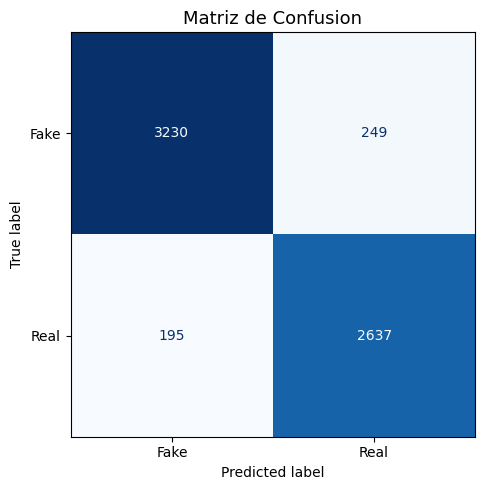

In [ ]:
# TODO: Matriz de confusion del mejor modelo
if max(history_glove["val_f1"]) >= max(history_random["val_f1"]):
    best_model, best_name = model_glove, "GloVe"
else:
    best_model, best_name = model_random, "Random"

print(f"Mejor modelo: TextCNN {best_name}")

test_metrics = evaluate_model(best_model, test_loader, criterion, device)
print(f"\n--- Métricas en Test ({best_name}) ---")
for metric, value in test_metrics.items():
    print(f"  {metric:>10s}: {value:.4f}")

y_true, y_pred, _ = get_predictions(best_model, test_loader, device)
plot_confusion_matrix(y_true, y_pred, labels=["Fake", "Real"])


### ¿GloVe convergió más rápido? ¿Por qué?

Sí, el modelo con embeddings GloVe converge más rápido. Al haber sido entrenado en cientos de millones de palabras, desde la primera época el modelo ya tiene conocimiento semántico, sabe que palabras como "false", "hoax" y "misinformation" están cerca, mientras que los embeddings aleatorios parten desde ruido puro.

Esto se traduce en gradientes más útiles desde el inicio y menos épocas necesarias para alcanzar el mejor F1 de validación, como se confirmó en los resultados: GloVe alcanzó su mejor Val F1 en época 2 y el early stopping lo detuvo en época 5, mientras que Random necesitó las 10 épocas completas sin superarlo.

Sin embargo, con embed_dim=50 ninguno de los dos modelos superó a SVM (F1=0.9564) ni a Logistic Regression (F1=0.9440), lo que sugiere que con embeddings de mayor dimensión (100d o 300d) el TextCNN podría alcanzar el rango esperado de 0.95-0.97.